In [1]:
import pandas as pd
import matplotlib.pyplot as plt
orders = pd.read_excel('ecommerce_cleaned_data.xlsx', sheet_name='Orders')

In [2]:
orders.head()

,Order_ID,Customer_ID,Order_Date,Product_ID,Quantity,Unit_Price,Discount,Payment_Method
0,ORD000001,CUST02899,2026-06-05,PROD0149,2,1227.76,0.0,UPI
1,ORD000002,CUST01911,2025-12-31,PROD0129,3,4408.43,0.0,Net Banking
2,ORD000004,CUST02224,2025-01-08,PROD0184,1,2061.01,0.0,Credit Card
3,ORD000007,CUST02514,2025-04-15,PROD0148,4,5873.34,0.0,COD
4,ORD000009,CUST02133,2026-08-08,PROD0274,3,7691.06,0.0,UPI


In [4]:
orders['order_total']= orders['Quantity']*orders['Unit_Price']*(1-orders['Discount'])

In [5]:
# Reference date 
reference_date = orders['Order_Date'].max()

# RFM calculate
rfm= orders.groupby('Customer_ID').agg(
     Recency= ('Order_Date',lambda x: (reference_date-x.max()).days),
    frequency= ('Order_ID','nunique'),
    monetary= ('order_total','sum')
).reset_index()

rfm.head()


,Customer_ID,Recency,frequency,monetary
0,CUST00001,323,1,7286.367
1,CUST00002,291,5,69471.860
2,CUST00003,195,6,60121.460
3,CUST00004,70,4,47732.952
4,CUST00005,14,2,12415.512


In [6]:
# Recency
rfm['R_score']= pd.qcut(rfm['Recency'],q=5,labels=[5,4,3,2,1])

# Frequency
rfm['F_score']= pd.qcut(rfm['frequency'].rank(method='first'),q=5,labels=[1,2,3,4,5])

# Monetary
rfm['M_score']= pd.qcut(rfm['monetary'],q=5,labels=[1,2,3,4,5])

# RFM_Score 
rfm['RFM_score']= rfm['R_score'].astype(str)+ rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,Customer_ID,Recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,CUST00001,323,1,7286.367,1,1,1,111
1,CUST00002,291,5,69471.860,1,4,5,145
2,CUST00003,195,6,60121.460,2,4,5,245
3,CUST00004,70,4,47732.952,3,3,4,334
4,CUST00005,14,2,12415.512,5,1,1,511


In [7]:
rfm['Total_score'] = rfm['R_score'].astype(int) + rfm['F_score'].astype(int) + rfm['M_score'].astype(int)


print(rfm['Total_score'].value_counts().sort_index())

Total_score
3      84
4     146
5     170
6     235
7     283
8     282
9     251
10    246
11    237
12    214
13    188
14    146
15    107
Name: count, dtype: int64


In [8]:
rfm['Segment'] = pd.qcut(rfm['Total_score'], q=5, 
                          labels=['Lost Customer', 'At Risk', 'Potential Loyalist', 'Loyal Customer', 'Champion'])


rfm.groupby('Segment')['Total_score'].agg(['min','max'])

C:\Users\suraj\AppData\Local\Temp\ipykernel_14244\3956875829.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rfm.groupby('Segment')['Total_score'].agg(['min','max'])


,min,max
Segment,,
Lost Customer,3,6
At Risk,7,8
Potential Loyalist,9,10
Loyal Customer,11,12
Champion,13,15


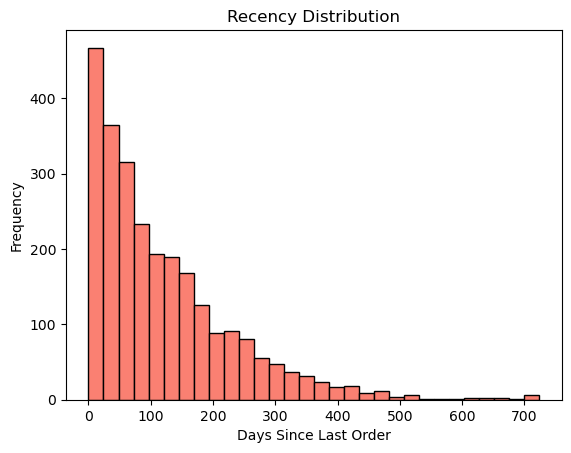

In [9]:
rfm['Recency'].plot(kind='hist',bins=30,color='salmon',edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Days Since Last Order')
plt.show()

In [10]:
rfm['Recency'].median()

87.0

In [11]:
CHURN_THRESHOLD = 90
rfm['churn_flag']= rfm['Recency'].apply(lambda x: 'Churned' if x>CHURN_THRESHOLD else 'Active')

rfm['churn_flag'].value_counts()

# Percentage bhi dekho
rfm['churn_flag'].value_counts(normalize=True)*100

churn_flag
Active     51.062186
Churned    48.937814
Name: proportion, dtype: float64

In [12]:
rfm['rfm_risk_level']= pd.qcut(rfm['Total_score'],q=3,labels=['High Risk', 'Medium Risk', 'Low Risk'])

def risk_score(row):
    if row['churn_flag']=='Churned':
        if row['monetary']>rfm['monetary'].median():
            return 'High Risk - High Value'
        else:
            return 'High Risk - Low Value'
    else:
        return row['rfm_risk_level']
        
rfm['risk_category']= rfm.apply(risk_score,axis=1)
rfm['risk_category'].value_counts()

risk_category
High Risk - Low Value     694
High Risk - High Value    573
Low Risk                  547
Medium Risk               517
High Risk                 258
Name: count, dtype: int64

## Revenue at Risk 

In [13]:
revenue_at_risk=rfm[rfm['churn_flag']=='Churned']['monetary'].sum()
total_revenue= rfm['monetary'].sum()
risk_percentage= (revenue_at_risk/total_revenue)*100
risk_percentage

print(f" Revenue at Risk : ₹{revenue_at_risk:,.2f}")
print(f"Risk Percentage: {risk_percentage: .2f}%")

 Revenue at Risk : ₹38,024,730.57
Risk Percentage:  44.08%


In [14]:
rfm.to_csv('rfm_analysis.csv',index=False)
print("RFM analysis saved!")

RFM analysis saved!
